# 02. Feature Engineering

Notebook ini melanjutkan data bersih dari `01_Data_Preprocessing.ipynb` untuk melakukan seleksi fitur, imputasi missing value, pengelompokan ulang target ke 4 kelas risiko kredit, normalisasi, dan pembagian dataset train/val/test.

**Pipeline notebook:** `00_Data_Exploration` → `01_Data_Preprocessing` → `02_Feature_Engineering` → `03_Modeling_ANN` → `04_Training_Evaluation` → `05_SHAP_Explainability` → `06_Deployment`

**Tahapan pada notebook ini:**
1. Seleksi 15 fitur terbaik (SelectKBest, F-statistic)
2. Imputasi missing value (median) pada fitur terpilih
3. Pengelompokan ulang target ke 4 kelas: Prime, Performing, Under-performing, Non-Performing
4. Normalisasi fitur (StandardScaler)
5. Pembagian dataset 70% train / 15% val / 15% test (stratified)
6. **Menyimpan seluruh artifact** (`imputer`, `scaler`, daftar fitur, label kelas, serta X_train/X_val/X_test/y_train/y_val/y_test) ke `artifacts/` dan `data/processed/` untuk dipakai notebook modeling.

---

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
import sys

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

sys.path.append('../src')
from io_utils import load_parquet, load_json, save_json, save_object, DATA_PROCESSED
import os

## Load Data Hasil Preprocessing (dari 01_Data_Preprocessing.ipynb)

In [2]:
df = load_parquet('loan_cleaned.parquet')
inverse_mapping = {int(k): v for k, v in load_json('inverse_mapping.json').items()}

print(f'Shape data bersih: {df.shape}')
df.head(3)

Shape data bersih: (887379, 27)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,target
0,5000.0,36.0,10.65,162.87,B,B2,10.0,RENT,24000.0,Verified,credit_card,27.65,0.0,1.0,NaN,3.0,0.0,13648.0,83.7,9.0,f,INDIVIDUAL,0.0,NaN,NaN,NaN,1
1,2500.0,60.0,15.27,59.83,C,C4,0.5,RENT,30000.0,Source Verified,car,1.00,0.0,5.0,NaN,3.0,0.0,1687.0,9.4,4.0,f,INDIVIDUAL,0.0,NaN,NaN,NaN,2
2,2400.0,36.0,15.96,84.33,C,C5,10.0,RENT,12252.0,Not Verified,small_business,8.72,0.0,2.0,NaN,2.0,0.0,2956.0,98.5,10.0,f,INDIVIDUAL,0.0,NaN,NaN,NaN,1


# **Seleksi Fitur: Top 15 Fitur**

Top 15 Fitur berdasarkan F-Statistic:


,Feature,F-Statistic,p-value
0,inq_last_6mths,5301.6321,0.0
1,int_rate,3288.0716,0.0
2,total_rev_hi_lim,1880.6773,0.0
3,term,1793.6562,0.0
4,tot_cur_bal,1415.1787,0.0
5,loan_amnt,1055.5650,0.0
6,open_acc,561.8435,0.0
7,dti,449.5162,0.0
8,installment,432.4557,0.0
9,revol_util,413.4907,0.0


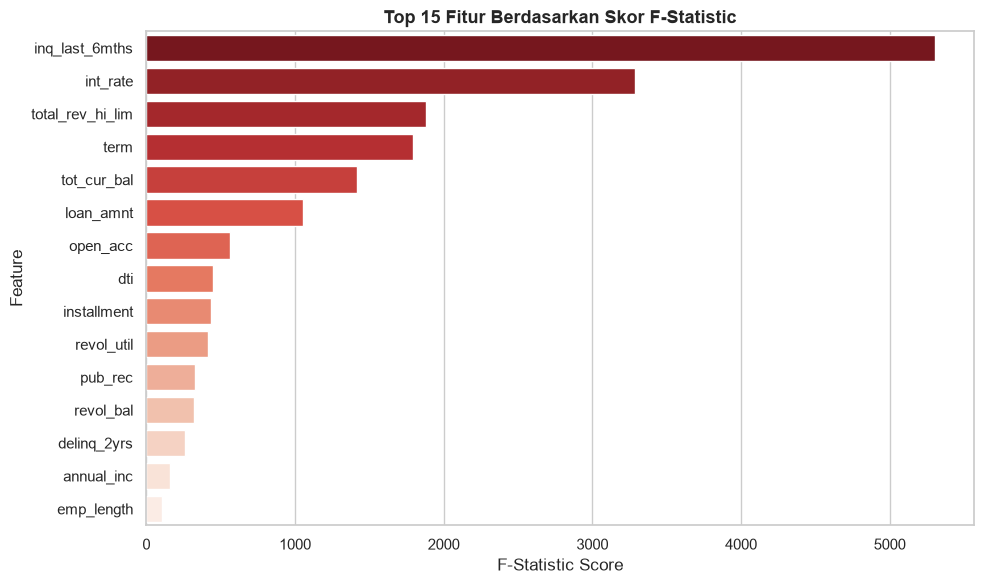

In [3]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.select_dtypes(include=['number']).drop(columns=['target'], errors='ignore')
y = df['target']

# Isi NaN sementara dengan 0 hanya untuk keperluan perhitungan skor
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X.fillna(0), y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Statistic': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values(by='F-Statistic', ascending=False).reset_index(drop=True)

top_15_features = feature_scores.head(15)

print("Top 15 Fitur berdasarkan F-Statistic:")
display(top_15_features.round(4))

plt.figure(figsize=(10, 6))
sns.barplot(x='F-Statistic', y='Feature', data=top_15_features, palette='Reds_r')
plt.title("Top 15 Fitur Berdasarkan Skor F-Statistic", fontsize=13, fontweight='bold')
plt.xlabel("F-Statistic Score")
plt.tight_layout()
plt.show()

## Imputasi Missing Value pada Fitur Terpilih

In [4]:
from sklearn.impute import SimpleImputer

# Ambil top 15 fitur + target
selected_features = top_15_features['Feature'].tolist()
df_model = df[selected_features + ['target']].copy()

print(f"Shape sebelum imputasi: {df_model.shape}")
print(f"\nMissing values per fitur:\n{df_model[selected_features].isnull().sum()[df_model[selected_features].isnull().sum() > 0]}")

# Imputasi dengan median
imputer = SimpleImputer(strategy='median')
df_model[selected_features] = imputer.fit_transform(df_model[selected_features])

print(f"\nMissing values setelah imputasi: {df_model.isnull().sum().sum()}")

Shape sebelum imputasi: (887379, 16)

Missing values per fitur:
inq_last_6mths         29
total_rev_hi_lim    70276
tot_cur_bal         70276
open_acc               29
revol_util            502
pub_rec                29
delinq_2yrs            29
annual_inc              4
emp_length          44825
dtype: int64

Missing values setelah imputasi: 0


## Pengelompokan Ulang Target ke 4 Kelas

In [5]:
# Remap loan_status ke 4 kelas
# Prime=0, Performing=1, Under-performing=2, Non-Performing=3
status_4class = {
    'Fully Paid':         0,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Current':            1,
    'Issued':             1,
    'In Grace Period':    2,
    'Late (16-30 days)':  2,
    'Late (31-120 days)': 3,
    'Charged Off':        3,
    'Default':            3,
    'Does not meet the credit policy. Status:Charged Off': 3,
}

# Buat mapping langsung: integer_lama → kelas_baru
# inverse_mapping sudah ada: {int → nama_status}
int_to_4class = {
    int_val: status_4class[nama]
    for int_val, nama in inverse_mapping.items()
    if nama in status_4class
}

df_model['risk_class'] = df_model['target'].map(int_to_4class)
df_model = df_model.drop(columns=['target'])
df_model = df_model.dropna(subset=['risk_class'])
df_model['risk_class'] = df_model['risk_class'].astype(int)

label_names = {0: 'Prime', 1: 'Performing', 2: 'Under-performing', 3: 'Non-Performing'}
print("Distribusi kelas baru:")
for k, v in df_model['risk_class'].value_counts().sort_index().items():
    print(f"  {k} ({label_names[k]}): {v:,} ({v/len(df_model)*100:.1f}%)")

Distribusi kelas baru:
  0 (Prime): 209,711 (23.6%)
  1 (Performing): 610,239 (68.8%)
  2 (Under-performing): 8,610 (1.0%)
  3 (Non-Performing): 58,819 (6.6%)


## Normalisasi Fitur (StandardScaler)

In [6]:
from sklearn.preprocessing import StandardScaler

X = df_model[selected_features].copy()
y = df_model['risk_class'].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=selected_features, index=X.index)

print("Normalisasi selesai (StandardScaler).")
print(f"Mean fitur setelah scaling (seharusnya ~0):\n{X_scaled.mean().round(4)}")
print(f"\nStd fitur setelah scaling (seharusnya ~1):\n{X_scaled.std().round(4)}")

Normalisasi selesai (StandardScaler).
Mean fitur setelah scaling (seharusnya ~0):
inq_last_6mths     -0.0
int_rate            0.0
total_rev_hi_lim   -0.0
term               -0.0
tot_cur_bal        -0.0
loan_amnt           0.0
open_acc            0.0
dti                -0.0
installment         0.0
revol_util         -0.0
pub_rec            -0.0
revol_bal           0.0
delinq_2yrs        -0.0
annual_inc          0.0
emp_length          0.0
dtype: float64

Std fitur setelah scaling (seharusnya ~1):
inq_last_6mths      1.0
int_rate            1.0
total_rev_hi_lim    1.0
term                1.0
tot_cur_bal         1.0
loan_amnt           1.0
open_acc            1.0
dti                 1.0
installment         1.0
revol_util          1.0
pub_rec             1.0
revol_bal           1.0
delinq_2yrs         1.0
annual_inc          1.0
emp_length          1.0
dtype: float64


## Pembagian Dataset (70% Train / 15% Val / 15% Test)

In [7]:
from sklearn.model_selection import train_test_split

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train : {X_train.shape[0]:,} samples ({len(X_train)/len(X_scaled)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]:,} samples ({len(X_val)/len(X_scaled)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} samples ({len(X_test)/len(X_scaled)*100:.0f}%)")

# Verifikasi distribusi kelas tetap proporsional
print("\nDistribusi kelas di train set:")
for k, v in pd.Series(y_train).value_counts().sort_index().items():
    print(f"  {label_names[k]}: {v:,} ({v/len(y_train)*100:.1f}%)")

Train : 621,165 samples (70%)
Val   : 133,107 samples (15%)
Test  : 133,107 samples (15%)

Distribusi kelas di train set:
  Prime: 146,798 (23.6%)
  Performing: 427,167 (68.8%)
  Under-performing: 6,027 (1.0%)
  Non-Performing: 41,173 (6.6%)


## Menyimpan Artifact untuk Tahap Modeling

In [8]:
# Simpan objek transformasi (untuk dipakai ulang saat inference/deployment)
save_object(imputer, 'imputer.pkl')
save_object(scaler, 'scaler.pkl')

# Simpan metadata
save_json(selected_features, 'selected_features.json')
save_json(label_names, 'label_names.json')

# Simpan dataset hasil split (parquet, gabung X+y agar mudah dibaca ulang)
train_df = X_train.copy(); train_df['risk_class'] = y_train.values
val_df = X_val.copy(); val_df['risk_class'] = y_val.values
test_df = X_test.copy(); test_df['risk_class'] = y_test.values

train_df.to_parquet(os.path.join(DATA_PROCESSED, 'train.parquet'), index=False)
val_df.to_parquet(os.path.join(DATA_PROCESSED, 'val.parquet'), index=False)
test_df.to_parquet(os.path.join(DATA_PROCESSED, 'test.parquet'), index=False)

print('Artifact tersimpan di artifacts/: imputer.pkl, scaler.pkl, '
      'selected_features.json, label_names.json')
print('Dataset tersimpan di data/processed/: train.parquet, val.parquet, test.parquet')
print(f'\nJumlah fitur: {len(selected_features)} -> {selected_features}')

Artifact tersimpan di artifacts/: imputer.pkl, scaler.pkl, selected_features.json, label_names.json
Dataset tersimpan di data/processed/: train.parquet, val.parquet, test.parquet

Jumlah fitur: 15 -> ['inq_last_6mths', 'int_rate', 'total_rev_hi_lim', 'term', 'tot_cur_bal', 'loan_amnt', 'open_acc', 'dti', 'installment', 'revol_util', 'pub_rec', 'revol_bal', 'delinq_2yrs', 'annual_inc', 'emp_length']


## Ringkasan & Langkah Selanjutnya

Dataset sudah terdiri dari 15 fitur terpilih, target 4 kelas risiko kredit, sudah dinormalisasi, dan sudah dibagi menjadi train/val/test dengan proporsi kelas yang terjaga (stratified split).